# Full trajectory analysis on elastica
Author: Pierre Maillard *pierre.maillard@epfl.ch*\
Release date: 28.05.2025



This python notebook is a guide to use **elastica** to solve a full trajectory case of a 1D ribbon model progress inside of a hyperelastic medium. This notebook assume that you already followed the guide to simulate simple load cases `Noto_elastica_ribbon_model.ipynb` and the interaction module for the quasi-static simulations  `Noto_elastica_sleeve_interaction.ipynb`. 

The ribbon model is developped by Basile Audoly and Sebastien Neukirch in *"A one-dimensional model for elastic ribbons: A little stretching makes a big difference"* **https://doi.org/10.1016/j.jmps.2021.104457**. 

The implementation of the model and all the specific functions related to the ribbon model are hard coded direclty inside of a merge code between the **elastica** source code and a modified version of **elastica** by Arman Tekinalp developped for this work *Topology, dynamics, and control of a muscle-architected soft arm* (**https://doi.org/10.1073/pnas.2318769121**).\
We use the source code of **elastica** that was available on February 2025 on the *github* page of GazzolaLab: **https://github.com/GazzolaLab/PyElastica** \
And Arman Tekinalp modified version available here: **https://github.com/GazzolaLab/topology-dynamics-control-of-a-muscle-architected-soft-arm** \
As the source-code of elastica has been modified and adapted, **DO NOT** install pyelastica direclty. You should be able to use directly the source code available beside this note book without having to pre-compile/install all **elastica** 'library'.

If you need to change a function related to the behavior of the ribbon or the solver. Go directly inside of the source code of **elastica** available beside this notebook and follow the **user_guide_ribbon_simulation.pdf** to find the portion of the code you need. Every post-processing and plotting function are define inside of the **src_plotting_ribbon.py** script. All informations related to the flow of data is described on the **user_guide_ribbon_simulation.pdf**.

In [1]:
#if you need to install the libraries just run this line
#%pip install -U -r requirements.txt

In [2]:
from elastica import *
from elastica.rod.ribbon1D import Ribbon1D
from elastica.rod.linear_ribbon1D import LinearRibbon1D

from elastica._linalg import _batch_norm
from elastica._linalg import _batch_cross

import os
import pickle
import numpy as np
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "notebook"

import pandas as pd
from collections import defaultdict
from matplotlib import pyplot as plt
from elastica.src_plotting_ribbon import *
from create_sim_env import *

## Trajectory simulation
To perform a trajectory simulation, we first have to choose a specific trajectory and descritized it into small quasi-static step. Here we use a *.csv* file that contains instructions on the trajectory and use those to create the discretized trajectories. We generate M step with N points each. These M steps will be solved independently by **elastica** and then analyse together as a full trajectory.

   type  length (mm)  curvature (1/mm)
0   arc    12.105954          0.066667
1  line    13.843567          0.000000
2   arc    12.197385         -0.066667
3  line     9.269020          0.000000


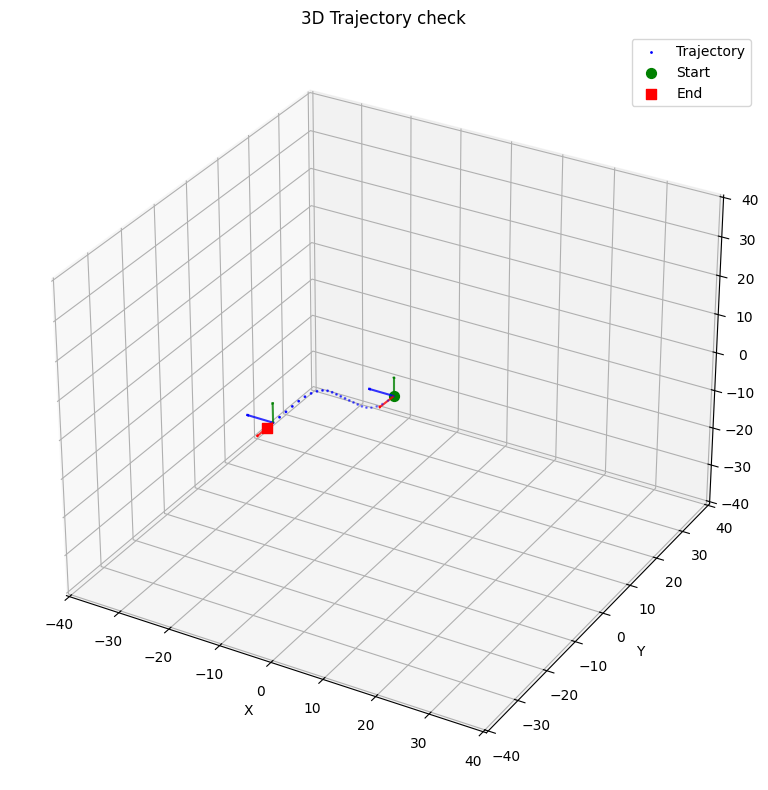

In [16]:
N_points = 25  #number of points in each step

direction = np.array([0,-1,0]) #direction of the ribbon (d3) in the laboratory frame at the base
normal = np.array([0,0,1])     #normal to the ribbon (d1) at the base

path_plan = pd.read_csv("path_0_0__15_-20__20_-40.csv")
#path_plan['twist (rad/mm)'] = [4*np.pi/180, 0, 0, 4*np.pi/180] # to easily add twist as an instruction on the .csv file
print(path_plan)

M = 2         # number of step in a path (typically 50 for final results)
min_length = 5 # length of the ribbon of the first step

paths_points, base_length, normals= build_incremental_discretized_paths(path_plan, direction, normal, N_points, M, min_length)

#choose the indice of a step and plot it to check the trajectory
idx = -1
plot_trajectory(paths_points[idx], normal_array = normals[idx],n_frames=2, frame_scale=5)
n_elem = paths_points[0].shape[1] -1 

## Run simulations: Full trajectory analysis
The next cell is an illustraction of the logic that is used inside of the ´run_trajectory.py´ script that is supposed to be run on the clusters. If you want to run the next cell keep M very low on the previous section or it will take ages to run. (`M=3`)

The logic used here (`for` + `while` loop) is very basic and could be improved. The `for` loop should be modified to parallelized the computation as all of the steps are independent from each other. (Create M small jobs on the cluster or allocate specfic cores to each step and run it on 1 job). The `while` loop is here to relunch the simulation if it fails after decreasing the time step (or even the P-controller constant) but if an other technic is used to stabilize the algorithm (like adaptive time-stepping) then it could be replaced.

Note that the function `create_env` is a compact way of perfoming the same initialization logic describe in the section **Simulation initialization: Quasi-static step** of `Noto_elastica_sleeve_interaction.ipynb`.

As a reminder, you can download solution from the cluster with **scp** function: 

`scp -r pmaillar@jed.hpc.epfl.ch:/home/pmaillar/Ribbon_interaction/result Ribbon_interaction_pyelastica/Ribbon_interaction`

In [41]:
kp = 0.6         #largest constant of the P-controller used for the pushing boundary condition at the base
final_time = 0.1 #final time [s] of all the step simulation

idx = 0

for stat, normal in zip(paths_points, normals):

    #initialize the position of the ribbon and the shape of the sleeve using the path discretized on the previous section
    d1_initial = normal
    initial_position = stat 
    sleeve_position = initial_position
    d1_sleeve = d1_initial

    #largest time step to try
    dt = 6e-8
    
    running = True
    while running:
        ribbon_output_list, sleeve_output_list, Ribbon_sim = create_env(initial_position, d1_initial, sleeve_position, d1_sleeve, 
                                                                        base_length = base_length[idx], dt = dt, 
                                                                        final_time = final_time, k_p_input_force = kp)
        timestepper = PositionVerlet()
        total_steps = int(final_time / dt)
        nan_detected, end_time = integrate(timestepper, Ribbon_sim, final_time, total_steps, time_display_up = 1)
        
        if nan_detected:
            if end_time > 1e4*dt:
                kp /=2
                print("New kp", kp)
            dt /=1.2
            print("New dt:",dt)
        else:
            running = False
            
        if dt<=1e-9:
            running = False
            print("dt set below tolerance. Break simulation")

        with open(f"result/trajectory_demo_{idx}.pickle", 'wb') as handle:
            pickle.dump(ribbon_output_list, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
        with open(f"result/trajectory_sleeve_demo_{idx}.pickle", 'wb') as handle:
            pickle.dump(sleeve_output_list, handle, protocol=pickle.HIGHEST_PROTOCOL)
            
    idx +=1

  0%|          | 26/1666666 [00:00<06:00, 4625.55it/s]


NaN detected at step 26 in system.
Final time of simulation is :  1.6200006480002604e-06
New dt: 5e-08


  0%|          | 31/2000000 [00:00<05:22, 6199.56it/s]


NaN detected at step 31 in system.
Final time of simulation is :  1.599999999999999e-06
New dt: 4.166666666666667e-08


  0%|          | 32/2400000 [00:00<04:59, 8012.52it/s]


...

NaN detected at step 139 in system.
Final time of simulation is :  5.833333333333321e-06
New dt: 3.4722222222222227e-08


  0%|          | 150/2880000 [00:00<05:45, 8334.27it/s]


NaN detected at step 150 in system.
Final time of simulation is :  5.243055555555556e-06
New dt: 2.893518518518519e-08


100%|██████████| 3455999/3455999 [06:52<00:00, 8372.98it/s]

Final time of simulation is :  0.09999999999053724


## Post processing: Full trajectory analysis
The post processing is not necessary to generate the final result of a full trajectory analysis but it is advised as it allows to check the convergence and quality of each step independently. All of the functions and logic used on the next sections are described in `Noto_elastica_ribbon_model.ipynb` and `Noto_elastica_sleeve_interaction.ipynb`.

In [11]:
#Choose wich step to inspect. Usely the first (0) and last (M-1) are the most critical steps.
idx = M - 10

#with open(f"result/trajectory_demo_{idx}.pickle", 'rb') as handle:
#    ribbon_output_list_read = pickle.load(handle)

#with open(f"result/trajectory_sleeve_demo_{idx}.pickle", 'rb') as handle:
#    sleeve_output_list_read = pickle.load(handle)

with open(f"result/simulation_data_{idx}.pickle", 'rb') as handle:
    ribbon_output_list_read = pickle.load(handle)

with open(f"result/simulation_data_sleeve_{idx}.pickle", 'rb') as handle:
    sleeve_output_list_read = pickle.load(handle)

    
solution_1 = process_solution_elastica(ribbon_output_list_read, base_length=base_length[idx])
solution_sleeve = process_solution_elastica_sleeve(sleeve_output_list_read)

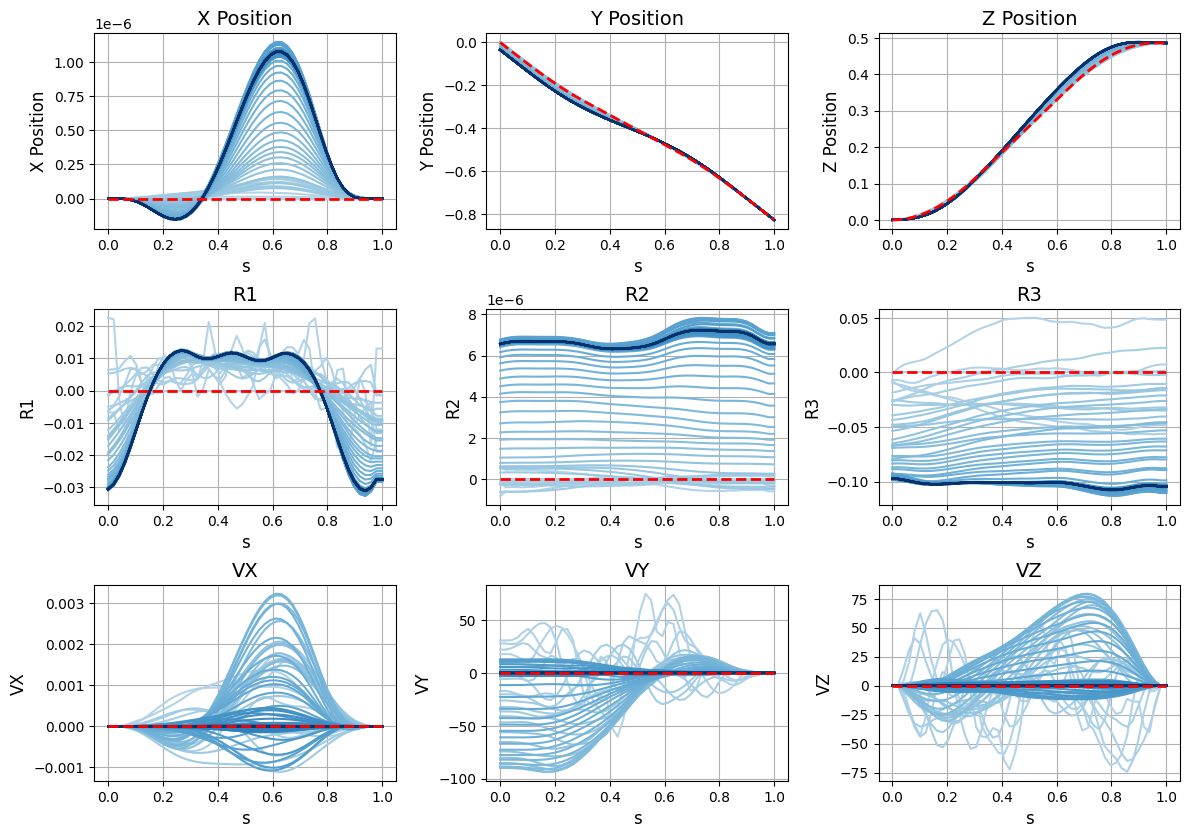

In [12]:
s = solution_1[solution_1.step ==0].s
d = { 's' : s, 
     'X' : paths_points[idx][0,:]/base_length[idx], 
     'Y' : paths_points[idx][1,:]/base_length[idx], 
     'Z': paths_points[idx][2,:]/base_length[idx],
     'R1': np.zeros_like(s),
     'R2': np.zeros_like(s),
     'R3': np.zeros_like(s),
     'VX': np.zeros_like(s),
     'VY': np.zeros_like(s),
     'VZ': np.zeros_like(s)
    }
true_solution_sleeve = pd.DataFrame(data = d)
true_solution_sleeve.head()

plot_multiple_solutions(
    solution_dfs=[solution_1],true_solution = true_solution_sleeve,
    labels=["Linear Ribbon"],
    indices=np.linspace(0,solution_1.Index_solution.max(),100,dtype=np.int64))

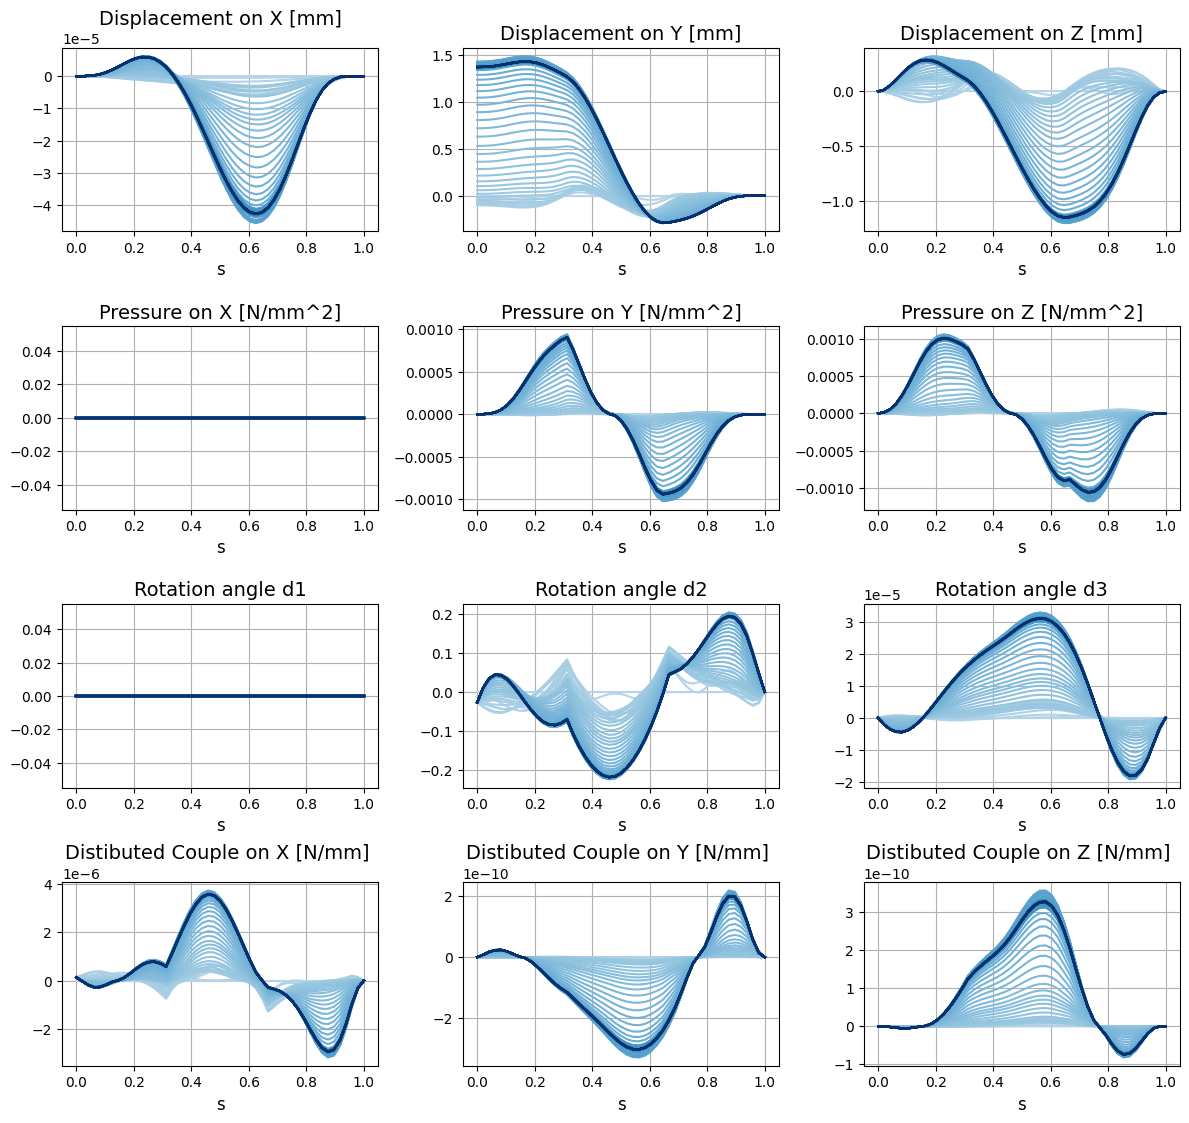

In [13]:
plot_multiple_solutions_sleeve(
    solution_dfs=[solution_sleeve], 
    labels = ["sleeve"], 
    indices = np.linspace(0,solution_sleeve.Index_solution.max(),100,dtype=np.int64))

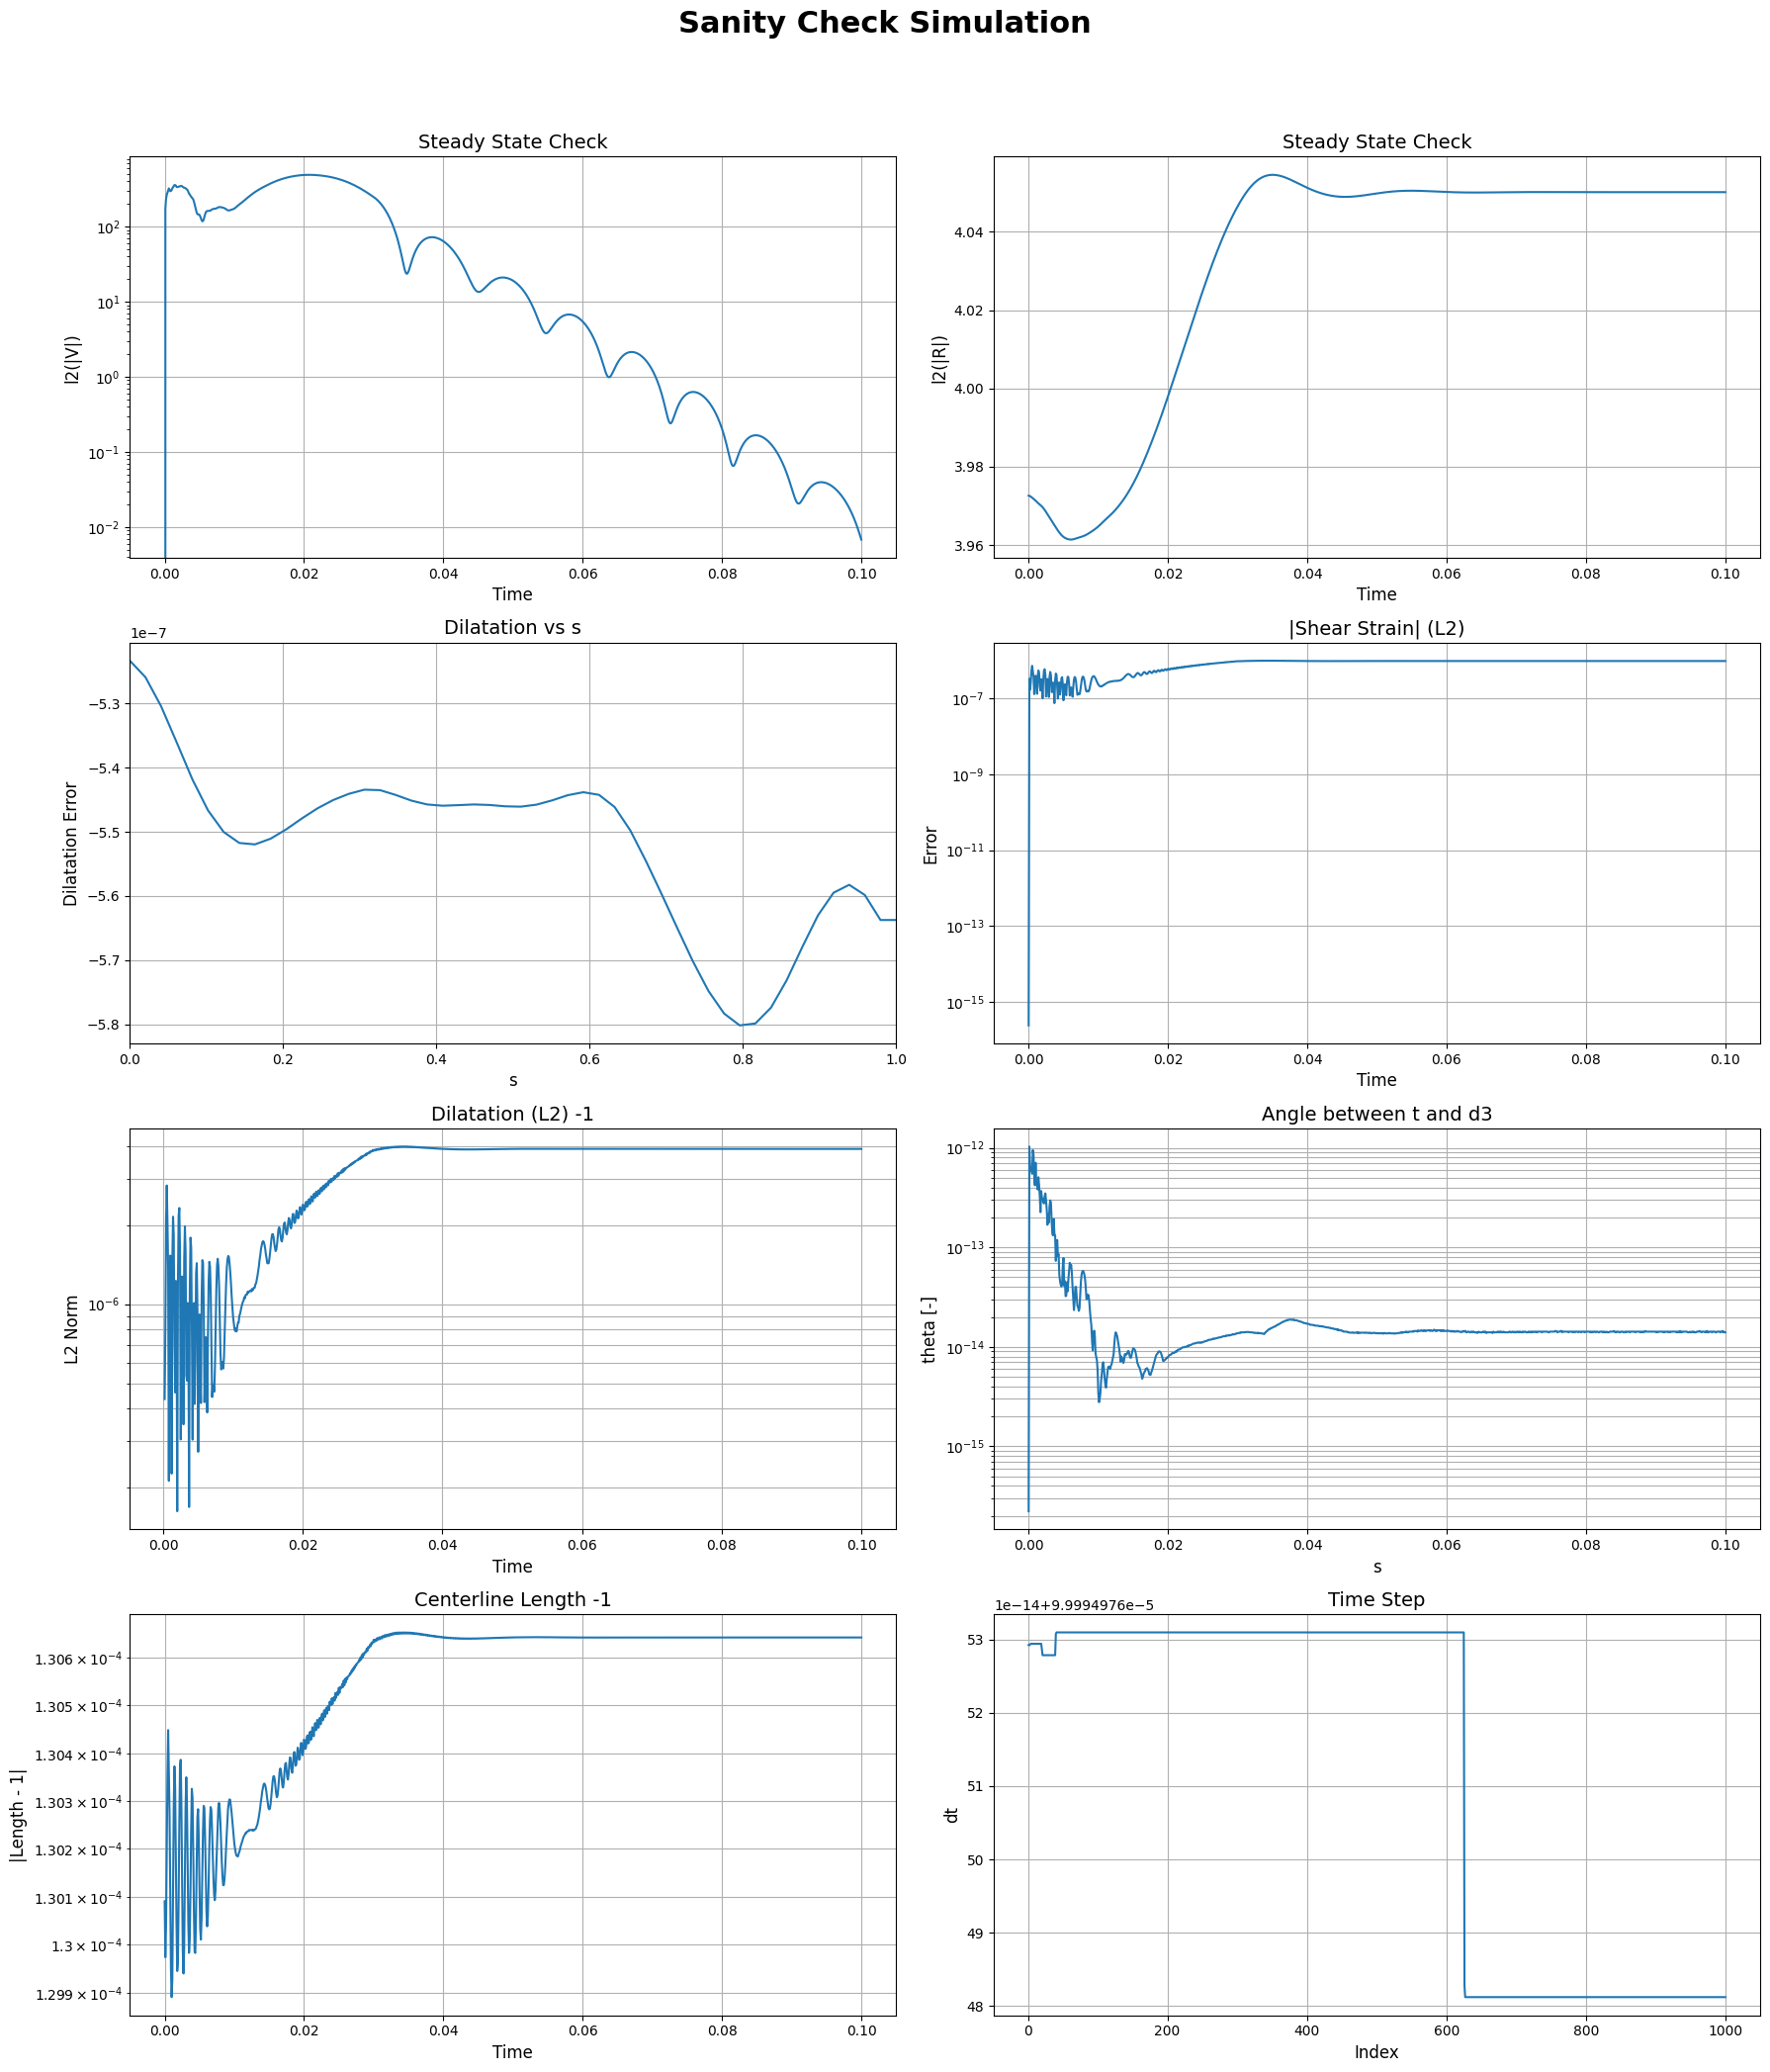

Final stress stat at s = 0:
R1: -3.0623e-02
R2: 6.5625e-06
R3: -9.7129e-02
Final stress stat at s = 1:
R1: -2.7584e-02
R2: 6.5624e-06
R3: -1.0462e-01


In [14]:
sanity_check_plot(solution_1)

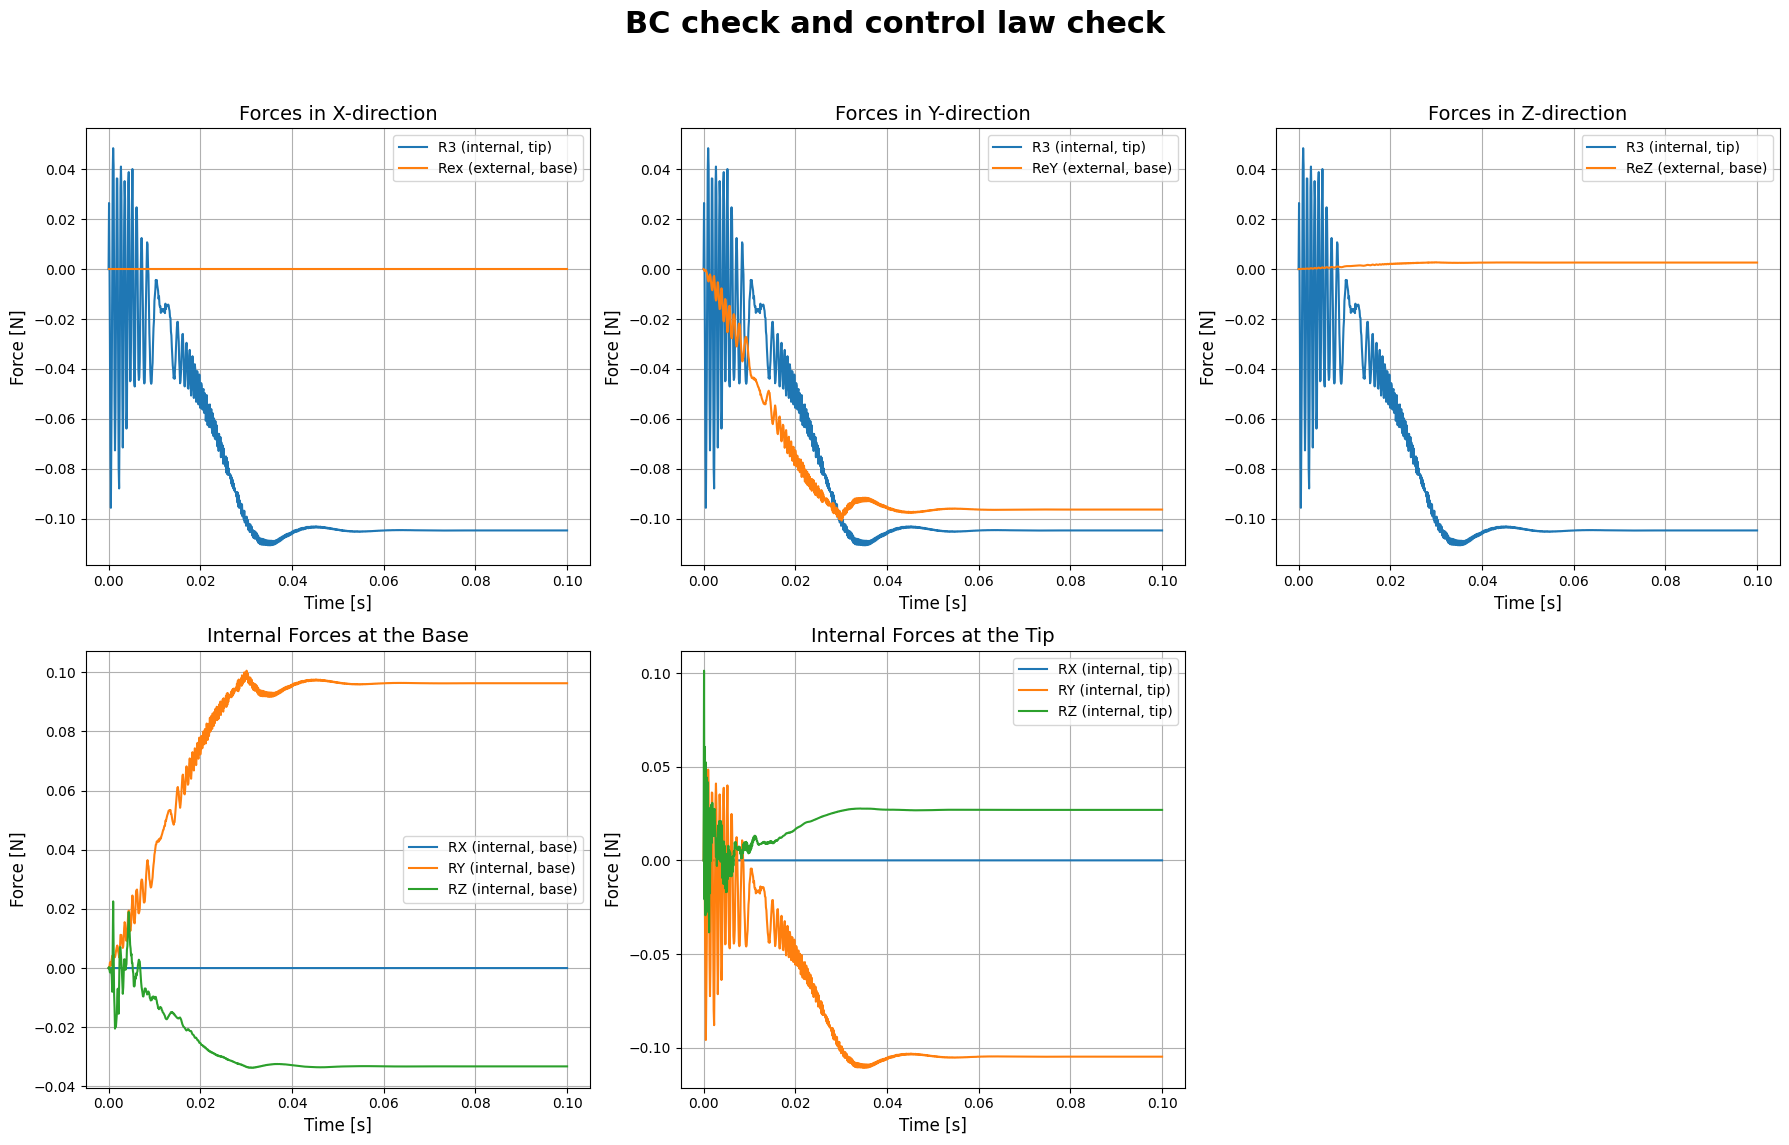

In [15]:
control_law_plot(solution_1)

## Create animation: Full trajectory analysis
The next cell extract all the solution from the `result` file (that would have been downloaded from the cluster) and process them to reconstructed the stress field on the ribbon surface. We then create an animation of the ribbon progress where each frame correspond to 1 quasi-static step.

To illustrate the code's functionality, we will use the solutions you generated in the last section. The result will therefore not be convincing given the very low value of `M`. 

To recontruct the stress field, we first project the pressure applied by the sleeve on the normal (d1) of the ribbon. Then we use the twisting couple that the sleeve apply (around d3) to deduce the repartition of the force along the width that would reproduce this amout of twist couple assuming that the repartition is linear (the force increase linearly along the width). 

This could be improved by recomputing the exact stress comming from the twist using the angle between the sleeve and the ribbon. We could also add the component of the stress from the bending angle between the ribbon and the sleeve. (wich is small compare to the other contribution but might be significant for highly bend trajectory)

   type  length (mm)  curvature (1/mm)
0   arc    12.105954          0.066667
1  line    13.843567          0.000000
2   arc    12.197385         -0.066667
3  line     9.269020          0.000000


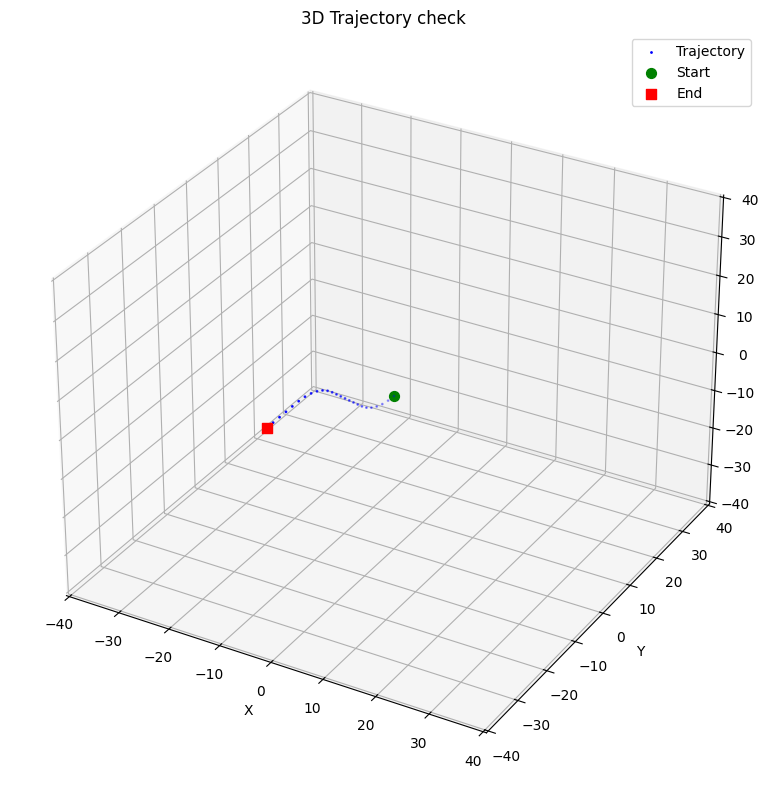

MovieWriter ffmpeg unavailable; using Pillow instead.


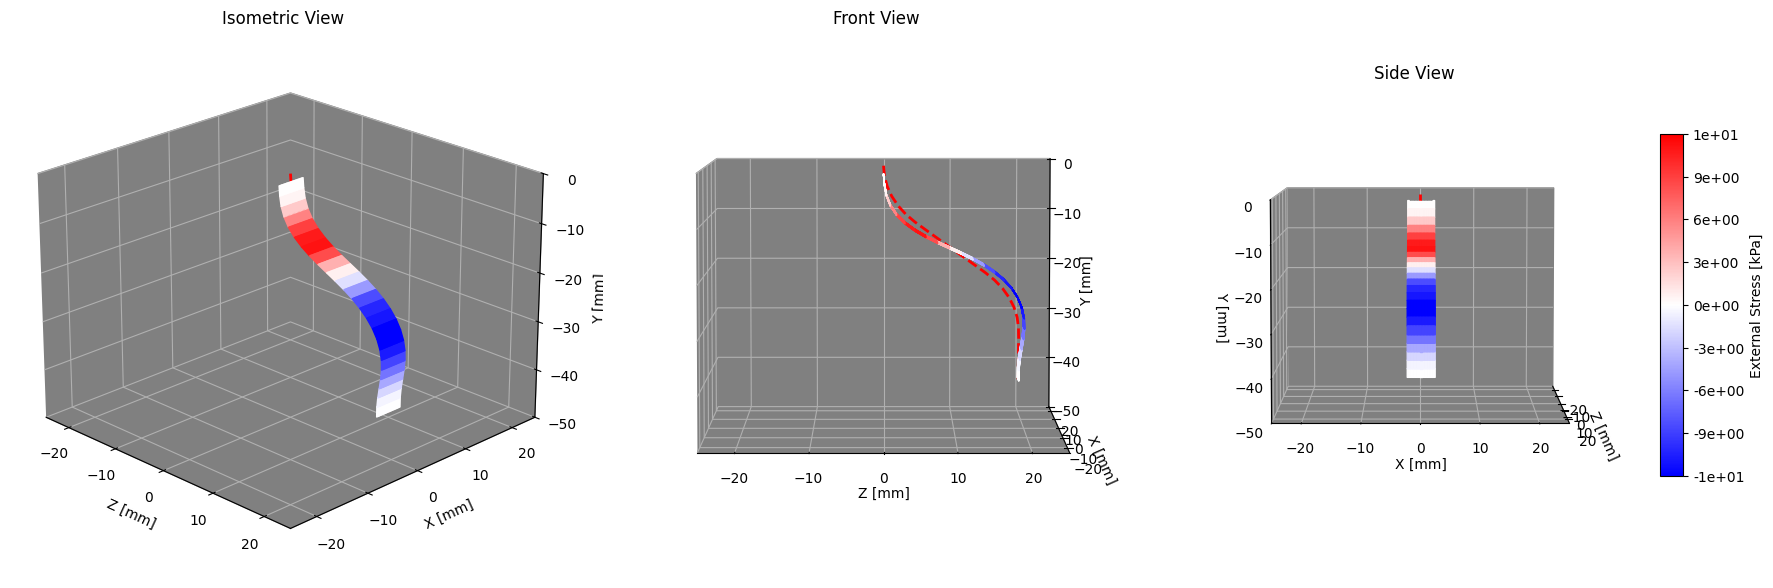

In [47]:
all_solutions = []
all_sleeves = []

N_points = 25

direction = np.array([0,-1,0])
normal = np.array([0,0,1])
path_plan = pd.read_csv("path_0_0__15_-20__20_-40.csv")
#path_plan['twist (rad/mm)'] = [4*np.pi/180, 0, 0, 4*np.pi/180] # to easily add twist as a instruction on the .csv file
print(path_plan)
M = 2 # number of step in a path
min_length = 5


paths_points, base_length, normals= build_incremental_discretized_paths(path_plan, direction, normal, N_points, M, min_length)
plot_trajectory(paths_points[-1])

n_elem = paths_points[0].shape[1] -1 

print("Extracting solutions ...")
for idx in range(M):
    
    with open(f"result/trajectory_demo_{idx}.pickle", 'rb') as handle:
        ribbon_output_list_read = pickle.load(handle)
    
    with open(f"result/trajectory_sleeve_demo_{idx}.pickle", 'rb') as handle:
        sleeve_output_list_read = pickle.load(handle)

    all_solutions.append(process_solution_elastica(ribbon_output_list_read, base_length=base_length[idx]))
    all_sleeves.append(process_solution_elastica_sleeve(sleeve_output_list_read))

print("Generating animation ...")
animate_stress_field_3views(
    all_solutions=all_solutions,
    all_sleeves=all_sleeves,
    all_path = paths_points, #give the path as argument only if you want to show the sleeve object (dotted red) at each step
    lengths=base_length, 
    a=5,
    max_frame=M-1,
    n_points=20,
    interval=4000,
    save_path = "anim_demo.gif",
)

Here is the code to generate the animation for the solution solved by the cluster.

   type  length (mm)  curvature (1/mm)
0   arc    12.105954          0.066667
1  line    13.843567          0.000000
2   arc    12.197385         -0.066667
3  line     9.269020          0.000000


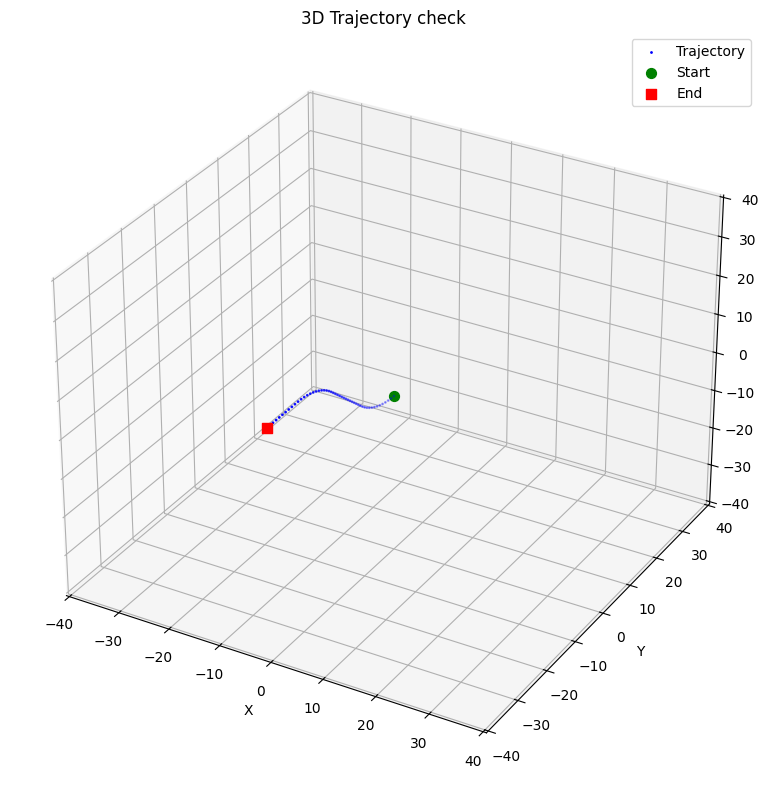

MovieWriter ffmpeg unavailable; using Pillow instead.


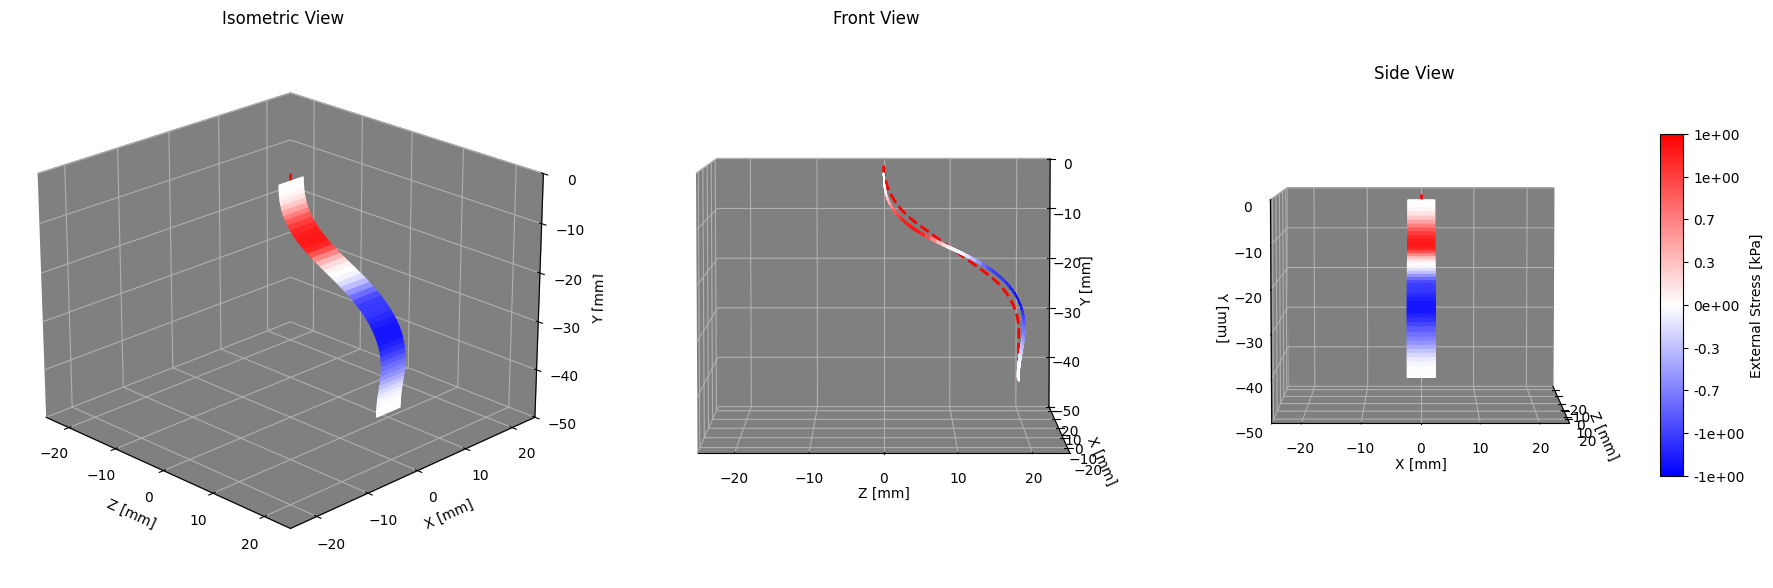

MovieWriter ffmpeg unavailable; using Pillow instead.


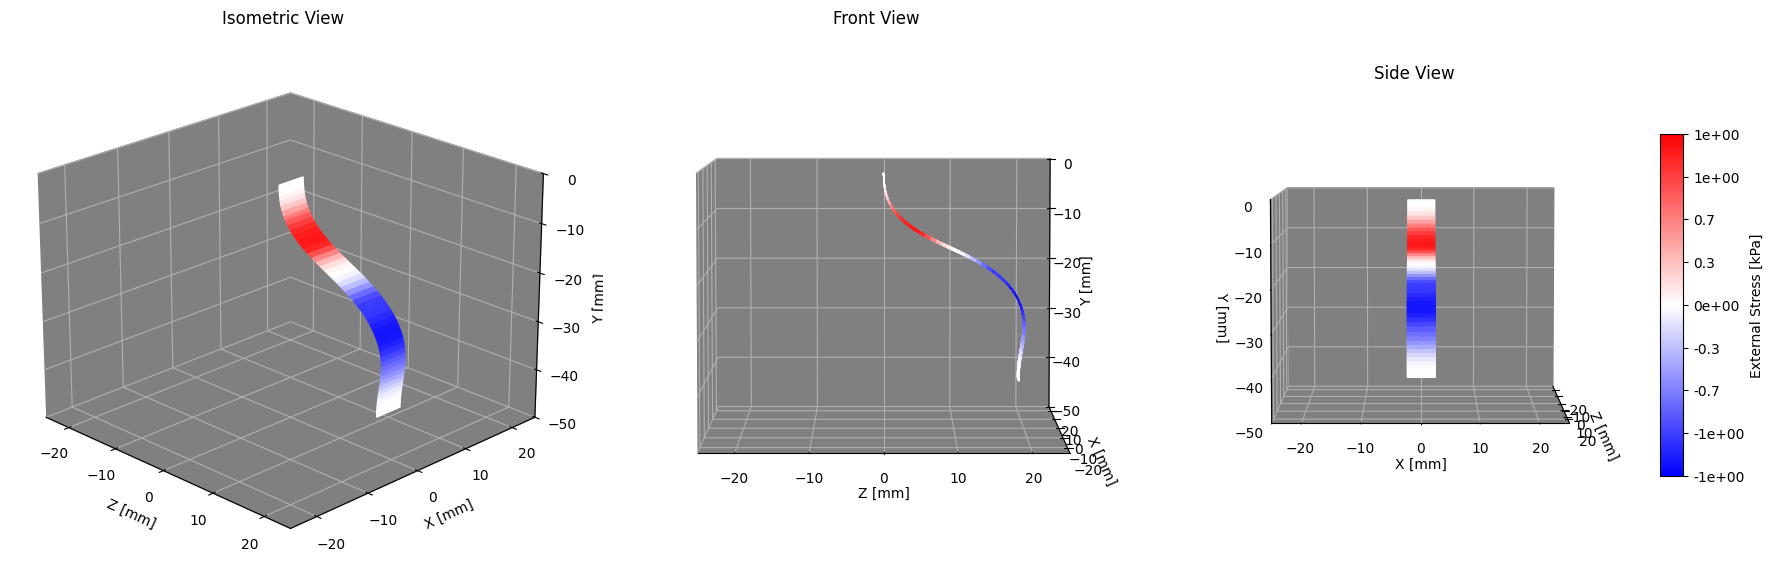

In [3]:
all_solutions = []
all_sleeves = []

N_points = 50

direction = np.array([0,-1,0])
normal = np.array([0,0,1])
path_plan = pd.read_csv("path_0_0__15_-20__20_-40.csv")
#path_plan['twist (rad/mm)'] = [4*np.pi/180, 0, 0, 4*np.pi/180] # to easily add twist as a instruction on the .csv file
print(path_plan)
M = 50 # number of step in a path
min_length = 5


paths_points, base_length, normals= build_incremental_discretized_paths(path_plan, direction, normal, N_points, M, min_length)
plot_trajectory(paths_points[-1])

n_elem = paths_points[0].shape[1] -1 


for idx in range(M):
    
    with open(f"result/simulation_data_{idx}.pickle", 'rb') as handle:
        ribbon_output_list_read = pickle.load(handle)
    
    with open(f"result/simulation_data_sleeve_{idx}.pickle", 'rb') as handle:
        sleeve_output_list_read = pickle.load(handle)

    all_solutions.append(process_solution_elastica(ribbon_output_list_read, base_length=base_length[idx]))
    all_sleeves.append(process_solution_elastica_sleeve(sleeve_output_list_read))
    
animate_stress_field_3views(
    all_solutions=all_solutions,
    all_sleeves=all_sleeves,
    all_path = paths_points, #give the path as argument only if you want to show the sleeve object (dotted red) at each step
    lengths=base_length, 
    a=5,
    max_frame=M-1,
    n_points=20,
    interval=4000,
    save_path = "anim_sshape.gif",
)


animate_stress_field_3views(
    all_solutions=all_solutions,
    all_sleeves=all_sleeves,
    lengths=base_length, 
    a=5,
    max_frame=M-1,
    n_points=20,
    interval=4000,
    save_path = "anim_sshape_nopath.gif",
)